In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [ ]:
# Load the data from the CSV file
housing_data_path = '/content/drive/MyDrive/housing.csv'
housing_data = pd.read_csv(housing_data_path)

# Display the first few rows of the dataset to understand its structure
housing_data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
import pandas as pd

# Assuming housing_data is your DataFrame and it's already loaded
# Load your dataset if it's not already loaded
# housing_data = pd.read_csv('path/to/housing.csv')

# Calculate min and max for each numerical column
range_df = pd.DataFrame(index=housing_data.columns)
range_df['min'] = housing_data.min(numeric_only=True)
range_df['max'] = housing_data.max(numeric_only=True)

# Calculate the range by subtracting the min from the max
range_df['range'] = range_df['max'] - range_df['min']

# Display the ranges
print(range_df)


                           min          max        range
longitude            -124.3500    -114.3100      10.0400
latitude               32.5400      41.9500       9.4100
housing_median_age      1.0000      52.0000      51.0000
total_rooms             2.0000   39320.0000   39318.0000
total_bedrooms          1.0000    6445.0000    6444.0000
population              3.0000   35682.0000   35679.0000
households              1.0000    6082.0000    6081.0000
median_income           0.4999      15.0001      14.5002
median_house_value  14999.0000  500001.0000  485002.0000
ocean_proximity            NaN          NaN          NaN


In [ ]:
# Handling missing values
for column in housing_data.columns:
    if housing_data[column].isnull().any():
       if housing_data[column].dtype == 'float64' or housing_data[column].dtype == 'int64':
           housing_data[column].fillna(housing_data[column].median(), inplace=True)

# **graphical representation and statistical analysis. ​**

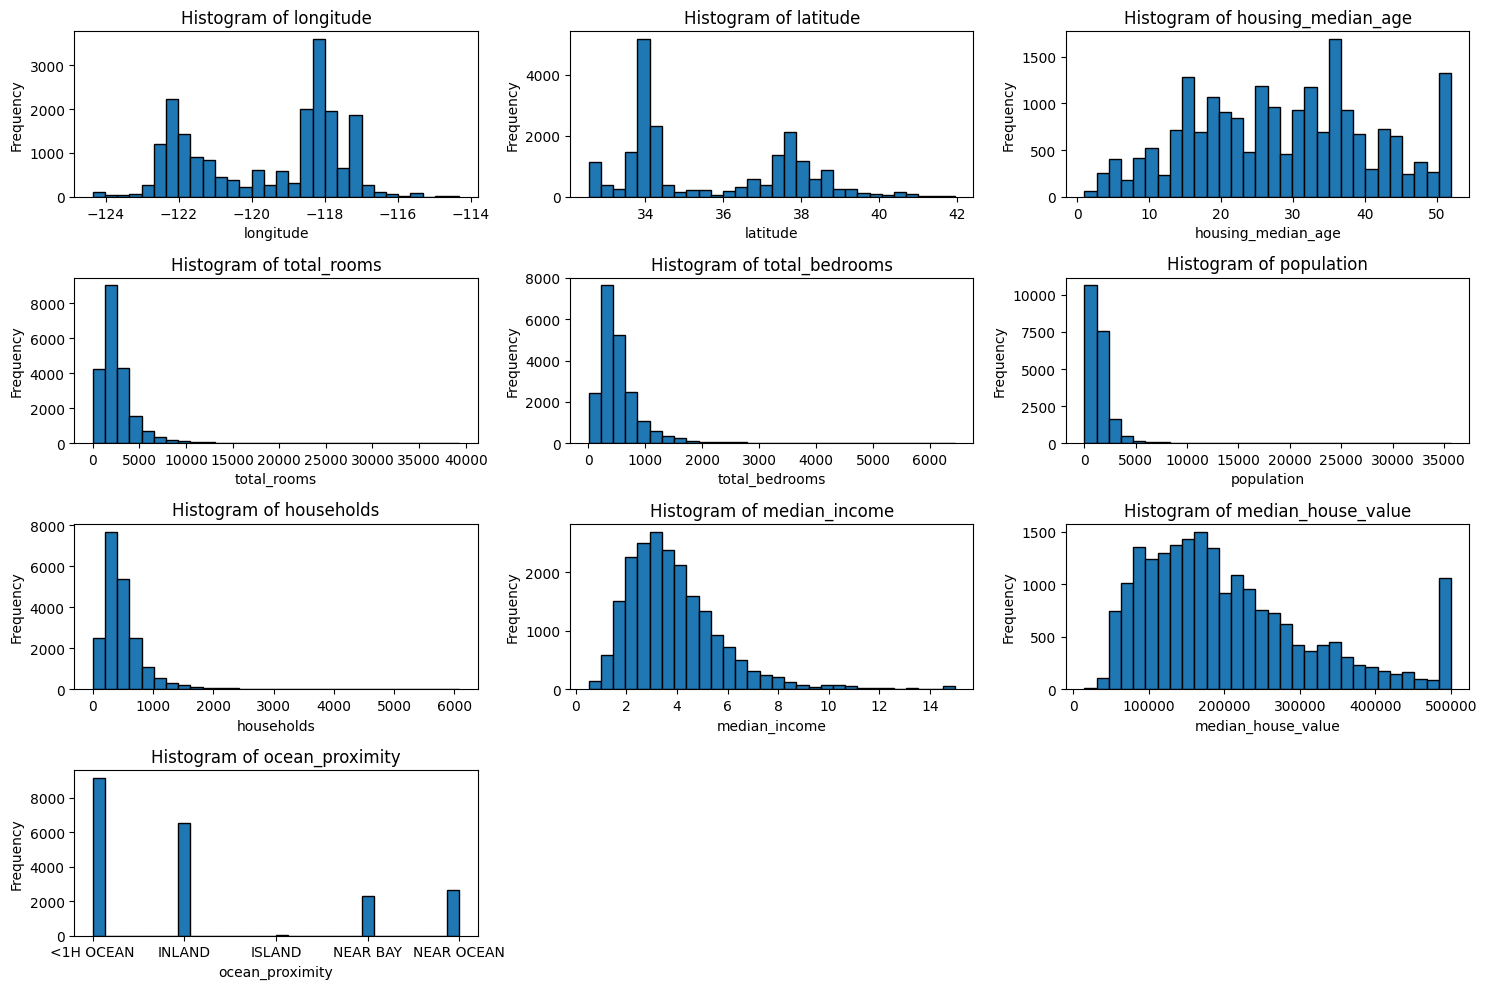

In [ ]:

# Step 1: Sort data by 'ocean_proximity' for demonstration (not numerically meaningful, but for illustrative purposes)
sorted_data = housing_data.sort_values(by='ocean_proximity')

# Step 2: Plotting each feature (selecting a few features for brevity and relevance)
# Note: Detailed individual feature analysis might require more specific plots.

# For demonstration, let's create histograms for a subset of numerical features.
features_to_plot = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity']

num_rows = 4
num_cols = 3

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))  # Adjust figsize as needed

# Flatten the axs array to iterate over each subplot
axs = axs.flatten()

for i, feature in enumerate(features_to_plot):
    axs[i].hist(sorted_data[feature], bins=30, edgecolor='black')
    axs[i].set_title(f'Histogram of {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(features_to_plot), num_rows*num_cols):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

plt.show()



In [ ]:
# Step 3: Compute and display descriptive statistics for the same subset of features.
descriptive_stats = sorted_data[features_to_plot].describe().T
descriptive_stats['mode'] = sorted_data[features_to_plot].mode().iloc[0]

# Add standard deviation
descriptive_stats['std_dev'] = sorted_data[features_to_plot].std()

descriptive_stats

<ipython-input-58-e9b1a6aa92a5>:6: FutureWarning: The default value of numeric_only in DataFrame.std is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  descriptive_stats['std_dev'] = sorted_data[features_to_plot].std()


,count,mean,std,min,25%,50%,75%,max,mode,std_dev
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100,-118.31,2.003532
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500,34.06,2.135952
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000,52.0,12.585558
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000,1527.0,2181.615252
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000,280.0,421.385070
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000,891.0,1132.462122
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000,306.0,382.329753
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001,3.125,1.899822
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000,500001.0,115395.615874


# **Correlation between features**

<ipython-input-27-d664e4aa271a>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = housing_data.corr()


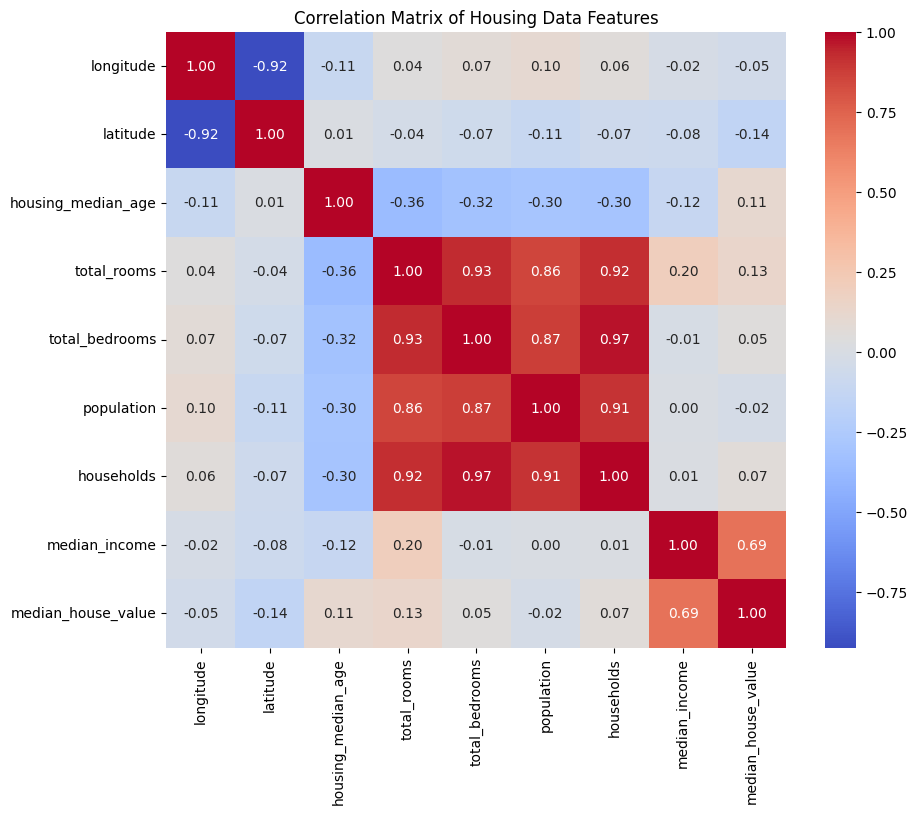

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069260,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066658,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.318998,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927253,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069260,-0.066658,-0.318998,0.927253,1.000000,0.873910,0.974725,-0.007682,0.049454
population,0.099773,-0.108785,-0.296244,0.857126,0.873910,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974725,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007682,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049454,-0.024650,0.065843,0.688075,1.000000


In [ ]:

correlation_matrix = housing_data.corr()

# Using a heatmap to visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Housing Data Features')
plt.show()

correlation_matrix


# **analyzing the feature distributions by ocean_proximity category.**

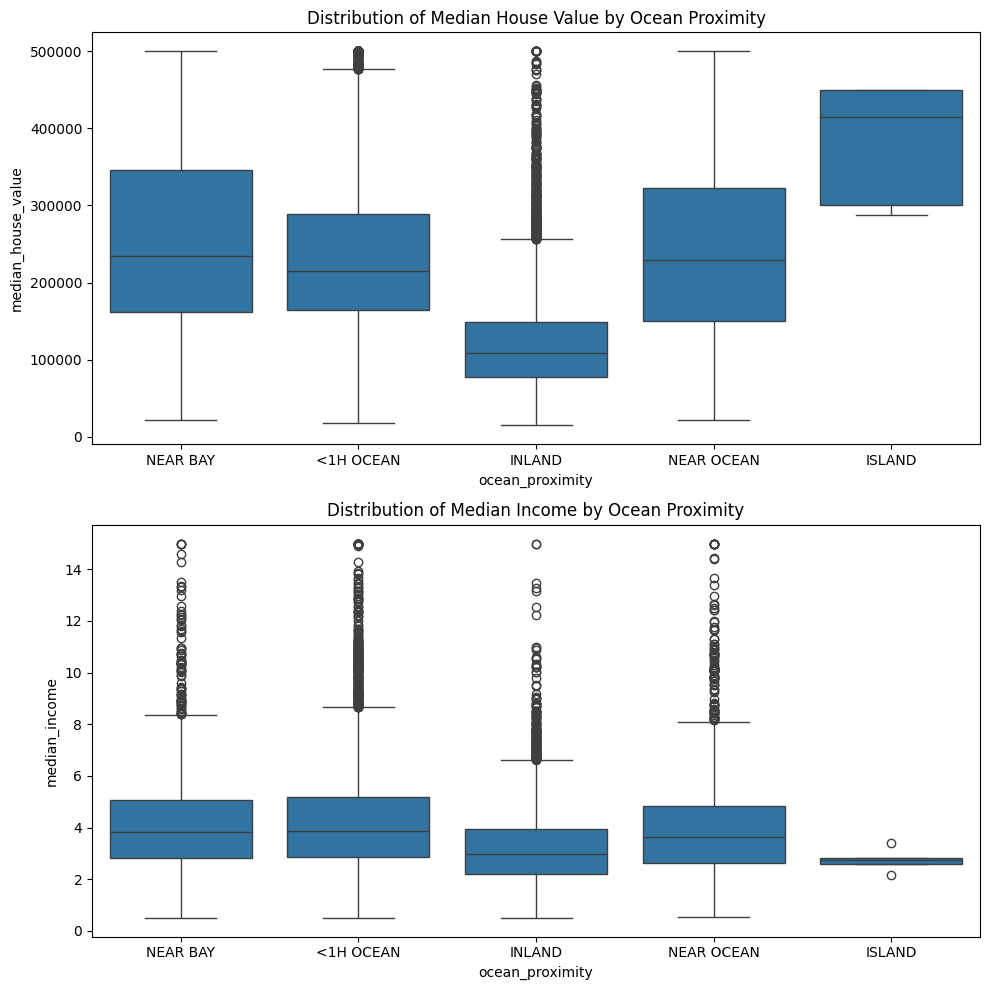

In [ ]:
# We'll visualize the median house value and median income as they are key features, grouped by ocean proximity

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Median House Value distribution by Ocean Proximity
sns.boxplot(x='ocean_proximity', y='median_house_value', data=housing_data, ax=axs[0])
axs[0].set_title('Distribution of Median House Value by Ocean Proximity')

# Median Income distribution by Ocean Proximity
sns.boxplot(x='ocean_proximity', y='median_income', data=housing_data, ax=axs[1])
axs[1].set_title('Distribution of Median Income by Ocean Proximity')

plt.tight_layout()
plt.show()


# **The correlation matrices for each ocean_proximity category reveal how relationships between features can vary depending on the geographical context:**

<ipython-input-29-d82096827a76>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')


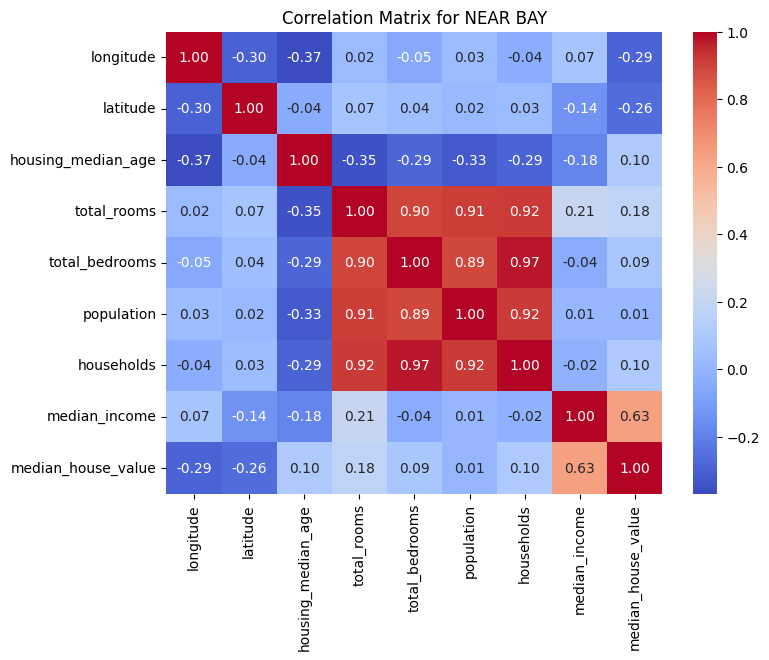

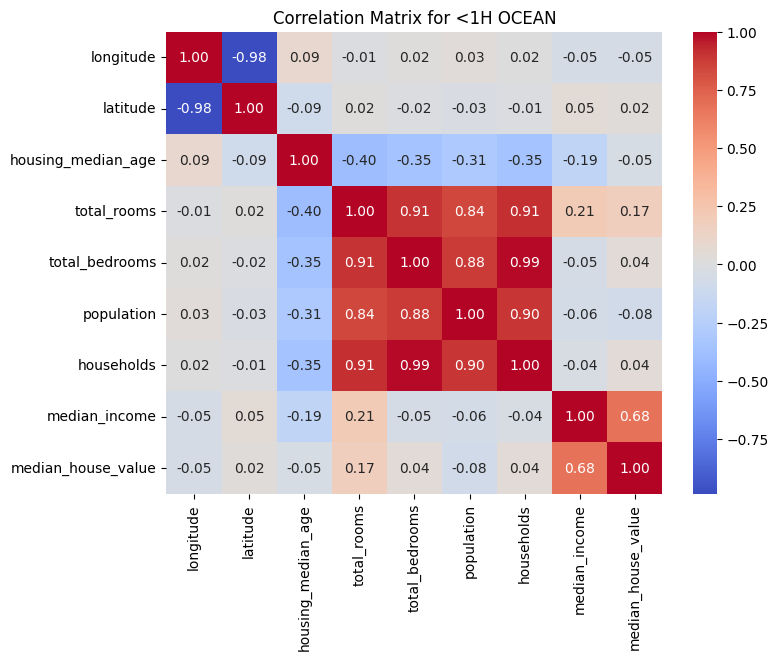

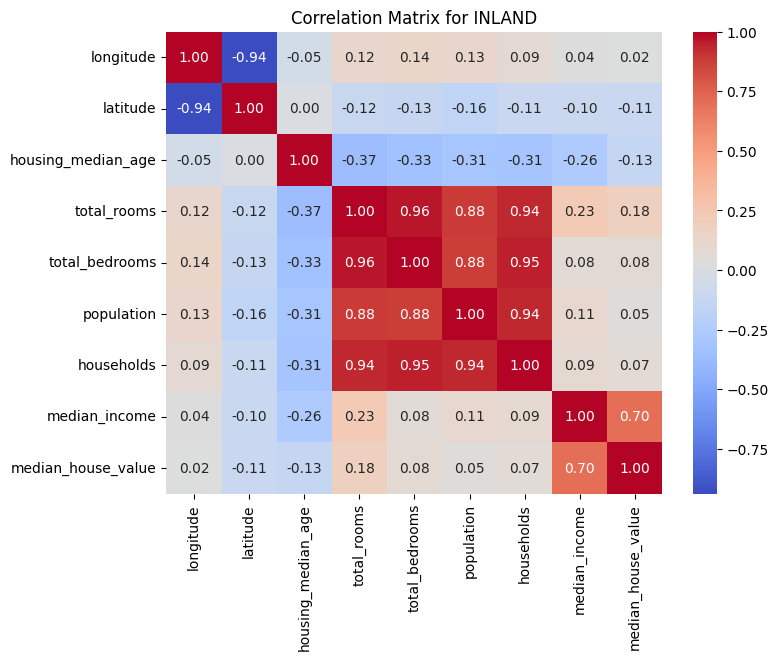

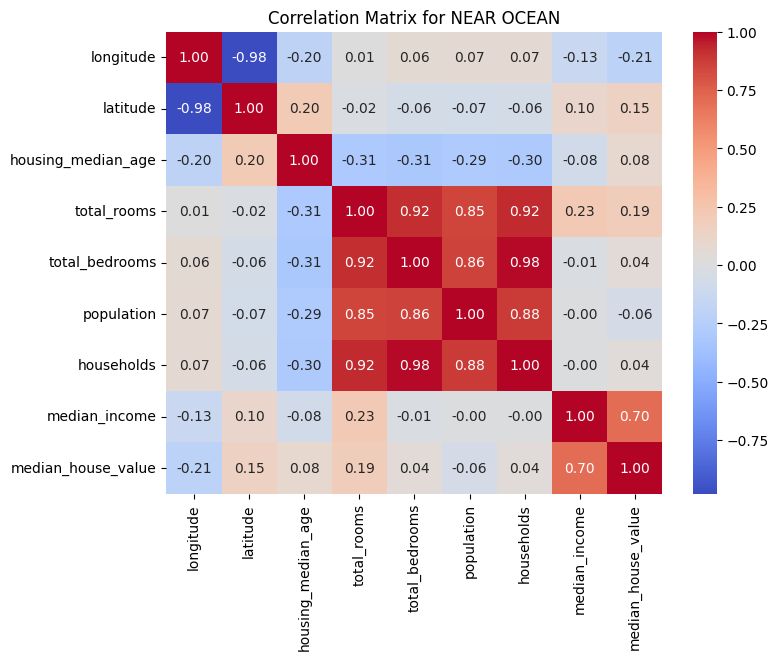

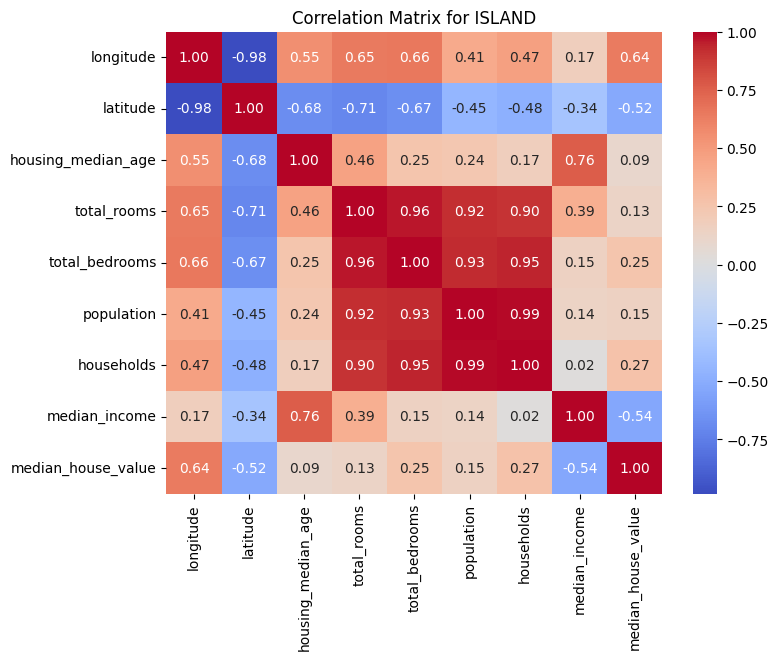

In [ ]:
# Step 3: Examine correlations of features within each 'ocean_proximity' category
# We'll compute and visualize the correlation matrix for each category

# Defining a function to compute and plot correlation matrix for a given subset of data
def plot_correlation(data, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(title)
    plt.show()

# Computing and plotting for each category
for category in housing_data['ocean_proximity'].unique():
    subset_data = housing_data[housing_data['ocean_proximity'] == category]
    plot_correlation(subset_data, f"Correlation Matrix for {category}")


# Preprocessing the Data

In [ ]:
# Handling missing values and scaling numerical features
numerical_features = housing_data.select_dtypes(include=['int64', 'float64']).columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# Encoding categorical features
categorical_features = ['ocean_proximity']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combining transformations into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

housing_prepared = preprocessor.fit_transform(housing_data)


# **Choosing the Number of Clusters (k)**

In [ ]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(housing_prepared)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()


# Running K-Means Clustering

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
housing_clusters = kmeans.fit_predict(housing_prepared)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
# Attach the cluster labels to the original data
housing_data['cluster'] = housing_clusters

# Analyze cluster characteristics
cluster_analysis = housing_data.groupby('cluster').mean()
print(cluster_analysis)


          longitude   latitude  housing_median_age   total_rooms  \
cluster                                                            
0       -117.951336  33.887648           30.847633   1889.385663   
1       -119.658387  35.244025           30.434432   2578.707924   
2       -119.209084  35.234837           18.600000   5409.558175   
3       -121.589920  38.004259           29.869261   1983.128261   
4       -118.856207  35.077310           11.972414  14089.596552   

         total_bedrooms   population   households  median_income  \
cluster                                                            
0            419.356047  1204.605345   392.457475       3.309779   
1            420.434564  1050.653576   400.276297       6.877246   
2           1124.961359  2881.826616  1039.501901       3.920461   
3            409.626981  1047.230870   377.220813       3.232153   
4           2674.778864  6951.193103  2429.317241       4.443876   

         median_house_value  
cluster         

<ipython-input-34-3ee8fc6199e7>:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cluster_analysis = housing_data.groupby('cluster').mean()


# **pre processing for linear regression**

In [ ]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# Identify numerical and categorical features
num_attribs = X.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = ['ocean_proximity']

In [ ]:
# Create a preprocessing pipeline for numerical attributes
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

In [ ]:
# Combine numerical and categorical transformations
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs),
])

In [ ]:
# Preprocess the data
X_prepared = full_pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2, random_state=42)


In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# Train the SVR model
svr = SVR(kernel='linear', C=100, epsilon=0.1)
svr.fit(X_train, y_train)


SVR(C=100, kernel='linear')

In [ ]:

# Make predictions and evaluate the model
y_pred = svr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')


Root Mean Squared Error: 72171.02835055794


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')


Mean Absolute Error: 49552.92402797716


In [ ]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f'Mean Absolute Percentage Error: {mape}%')


Mean Absolute Percentage Error: 25.903876052127252%


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')


R-squared: 0.602516663143657
